In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [ ]:
df = pd.read_csv('/content/ionosphere.csv')
df.head()

,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.1,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
0,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
1,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
2,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
3,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g
4,1,0,0.02337,-0.00592,-0.09924,-0.11949,-0.00763,-0.11824,0.14706,0.06637,...,-0.01535,-0.03240,0.09223,-0.07859,0.00732,0.00000,0.00000,-0.00039,0.12011,b


In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

y = y.map({'g': 1, 'b': 0})

print(X.shape)
print(y.value_counts())

(350, 34)
g
1    224
0    126
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "KNN": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Naive Bayes": GaussianNB(),

    "SVM (StandardScaler)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC())
    ]),

    "SVM (MinMaxScaler)": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", SVC())
    ])
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

results

{'Logistic Regression': 0.8857142857142857,
 'KNN': 0.8571428571428571,
 'Decision Tree': 0.8428571428571429,
 'Random Forest': 0.9428571428571428,
 'Naive Bayes': 0.9571428571428572,
 'SVM (StandardScaler)': 0.9571428571428572,
 'SVM (MinMaxScaler)': 0.9571428571428572}

Logistic Regression

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
Kfrom sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8857142857142857
Confusion Matrix:
 [[21  4]
 [ 4 41]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84        25
           1       0.91      0.91      0.91        45

    accuracy                           0.89        70
   macro avg       0.88      0.88      0.88        70
weighted avg       0.89      0.89      0.89        70



In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

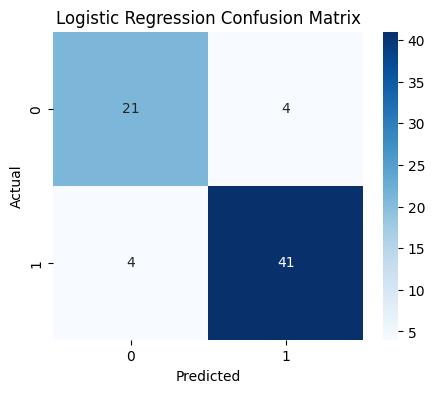

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

K_Neighbors(KNN)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
knn_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)

In [ ]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8571428571428571
Confusion Matrix:
 [[17  8]
 [ 2 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.68      0.77        25
           1       0.84      0.96      0.90        45

    accuracy                           0.86        70
   macro avg       0.87      0.82      0.83        70
weighted avg       0.86      0.86      0.85        70



In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

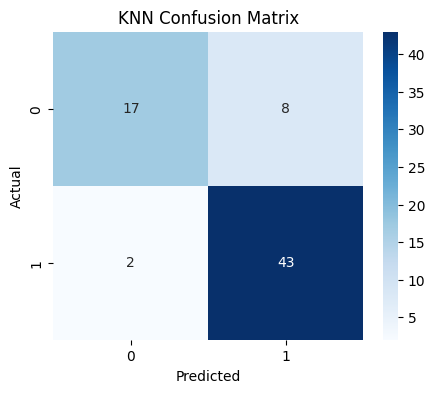

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [ ]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8571428571428571
Confusion Matrix:
 [[20  5]
 [ 5 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        25
           1       0.89      0.89      0.89        45

    accuracy                           0.86        70
   macro avg       0.84      0.84      0.84        70
weighted avg       0.86      0.86      0.86        70



In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

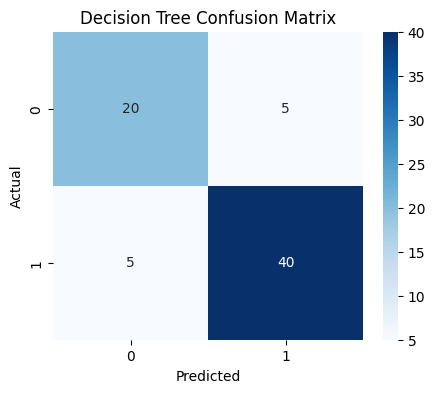

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9571428571428572
Confusion Matrix:
 [[24  1]
 [ 2 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94        25
           1       0.98      0.96      0.97        45

    accuracy                           0.96        70
   macro avg       0.95      0.96      0.95        70
weighted avg       0.96      0.96      0.96        70



In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

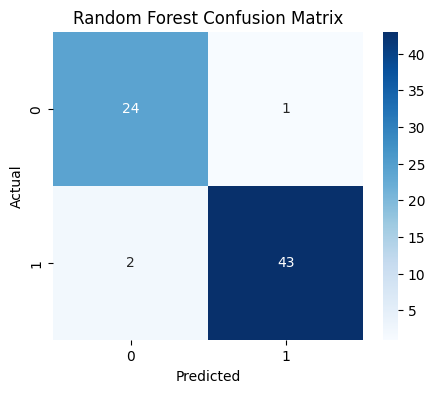

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Naive Baayes

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

In [ ]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9571428571428572
Confusion Matrix:
 [[22  3]
 [ 0 45]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.88      0.94        25
           1       0.94      1.00      0.97        45

    accuracy                           0.96        70
   macro avg       0.97      0.94      0.95        70
weighted avg       0.96      0.96      0.96        70



In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

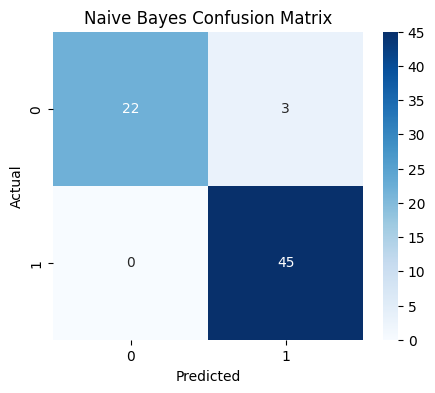

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM(StanderdScaler)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
svm_std_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

svm_std_pipeline.fit(X_train, y_train)
y_pred_svm_std = svm_std_pipeline.predict(X_test)

In [ ]:
print("SVM (StandardScaler) Accuracy:", accuracy_score(y_test, y_pred_svm_std))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_std))
print("Classification Report:\n", classification_report(y_test, y_pred_svm_std))

SVM (StandardScaler) Accuracy: 0.9571428571428572
Confusion Matrix:
 [[24  1]
 [ 2 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94        25
           1       0.98      0.96      0.97        45

    accuracy                           0.96        70
   macro avg       0.95      0.96      0.95        70
weighted avg       0.96      0.96      0.96        70



In [ ]:
cm_svm_std = confusion_matrix(y_test, y_pred_svm_std)

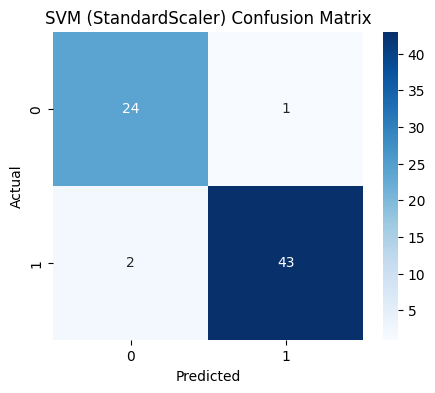

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm_std, annot=True, fmt='d', cmap='Blues')
plt.title("SVM (StandardScaler) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM(MinMaxScaler)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
svm_mm_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svm', SVC())
])

svm_mm_pipeline.fit(X_train, y_train)
y_pred_svm_mm = svm_mm_pipeline.predict(X_test)

In [ ]:
print("SVM (MinMaxScaler) Accuracy:", accuracy_score(y_test, y_pred_svm_mm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_mm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm_mm))

SVM (MinMaxScaler) Accuracy: 0.9571428571428572
Confusion Matrix:
 [[24  1]
 [ 2 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94        25
           1       0.98      0.96      0.97        45

    accuracy                           0.96        70
   macro avg       0.95      0.96      0.95        70
weighted avg       0.96      0.96      0.96        70



In [ ]:
cm_svm_mm = confusion_matrix(y_test, y_pred_svm_mm)

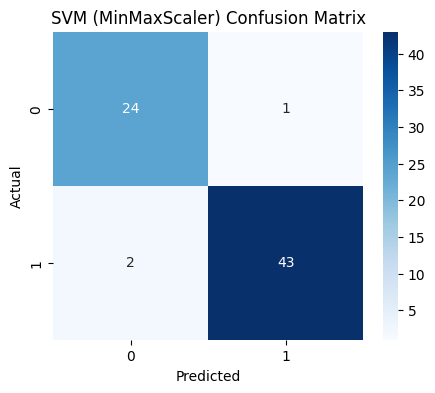

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm_mm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM (MinMaxScaler) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Result

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_summary = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'Naive Bayes': accuracy_score(y_test, y_pred_nb),
    'SVM (StandardScaler)': accuracy_score(y_test, y_pred_svm_std),
    'SVM (MinMaxScaler)': accuracy_score(y_test, y_pred_svm_mm)
}

In [ ]:
accuracy_df = pd.DataFrame(list(accuracy_summary.items()), columns=['Algorithm', 'Accuracy'])
accuracy_df

,Algorithm,Accuracy
0,Logistic Regression,0.885714
1,KNN,0.857143
2,Decision Tree,0.857143
3,Random Forest,0.957143
4,Naive Bayes,0.957143
5,SVM (StandardScaler),0.957143
6,SVM (MinMaxScaler),0.957143


/tmp/ipython-input-3385608319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Accuracy', data=accuracy_df, palette='viridis')


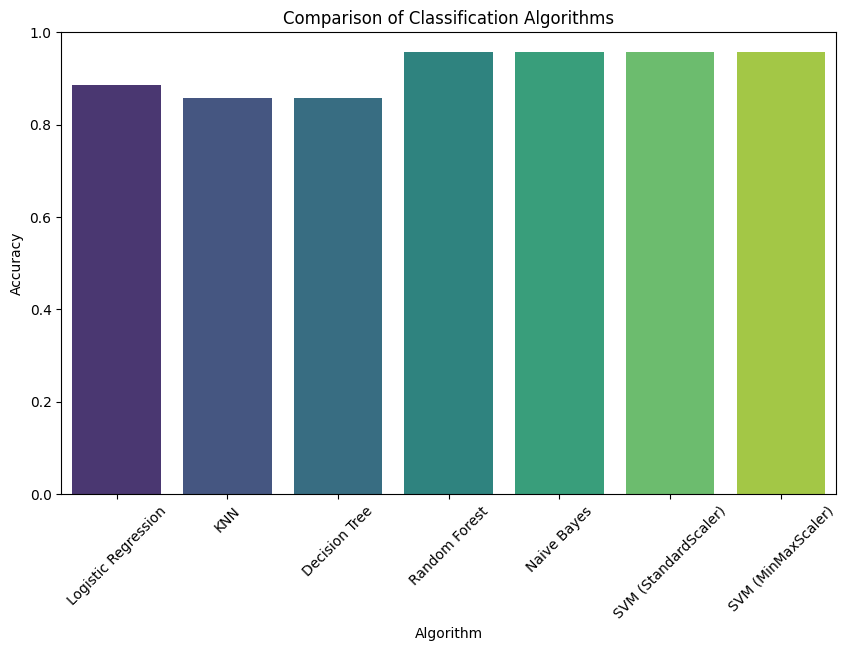

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Algorithm', y='Accuracy', data=accuracy_df, palette='viridis')
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Comparison of Classification Algorithms')
plt.xticks(rotation=45)
plt.show()